In [45]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


Моё решение:

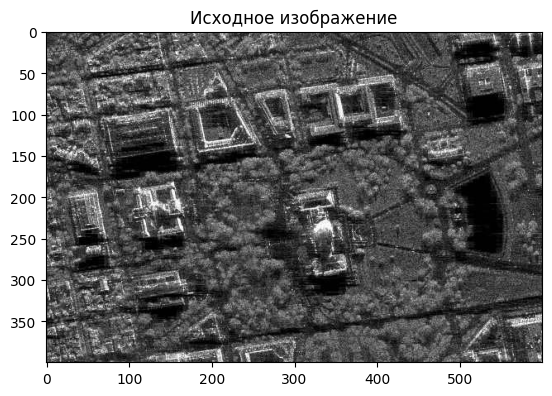

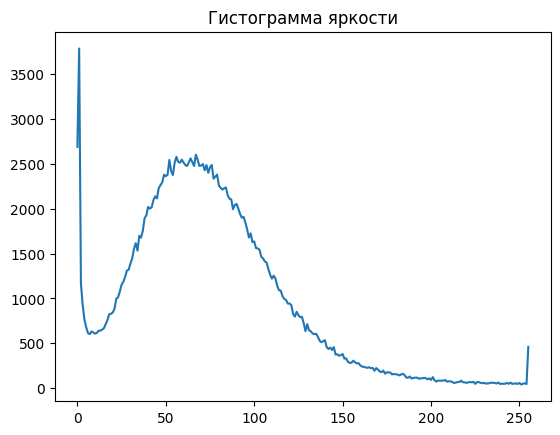

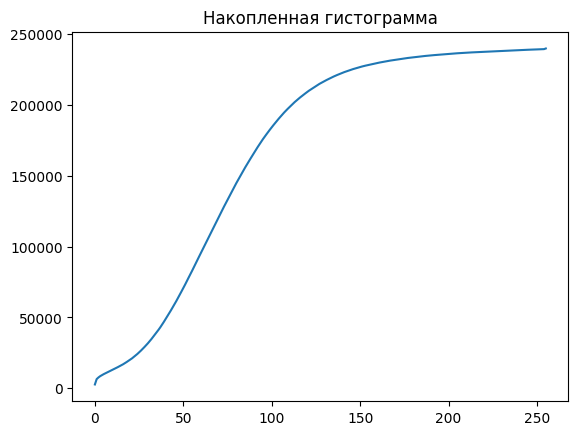

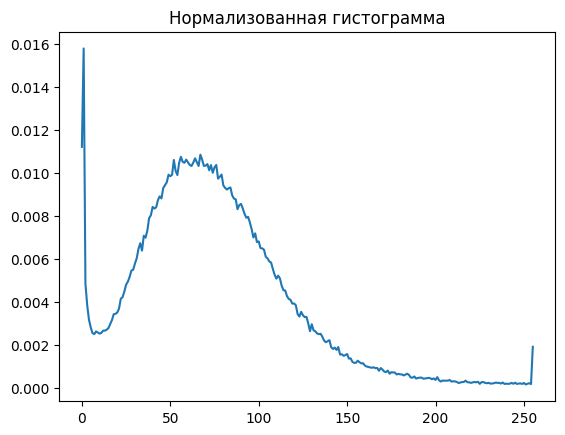

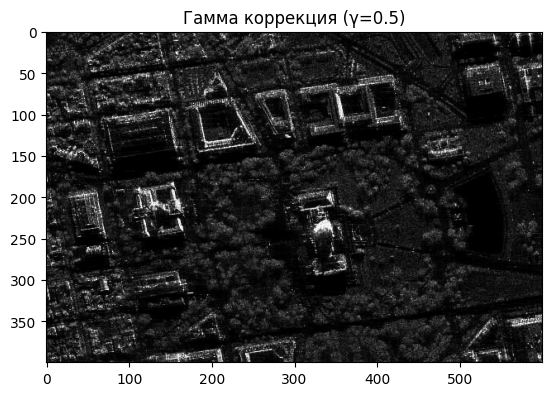

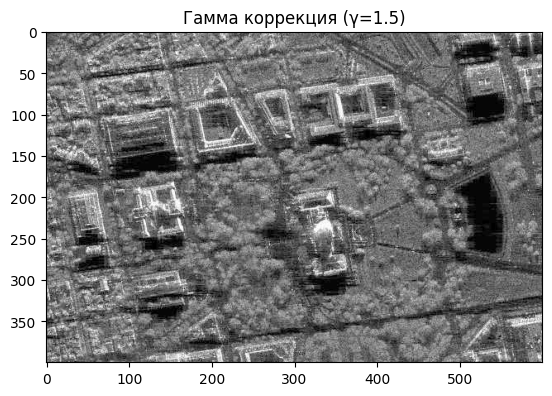

SSIM between source image and image with gamma 0.5: 0.5270459922820344
SSIM between source image and image with gamma 1.5: 0.8939717313812032
MSE between original image and image with gamma 0.5: 2383.7636375
MSE between original image and image with gamma 1.5: 1114.4519291666666


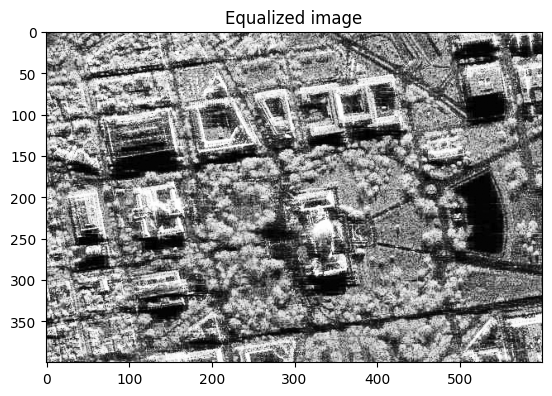

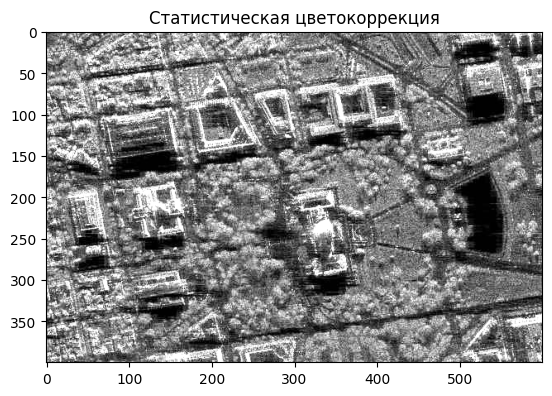

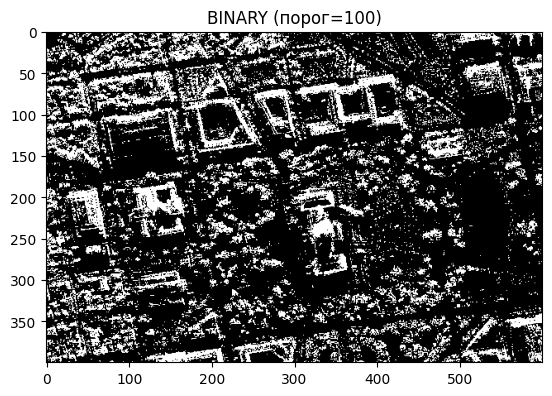

Порог 100 - BINARY: MSE=6596.7048


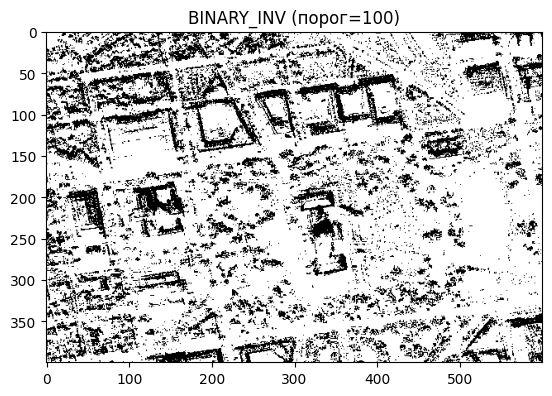

Порог 100 - BINARY_INV: MSE=35252.6953


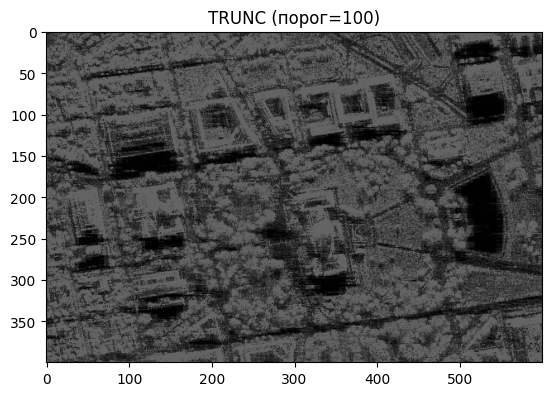

Порог 100 - THRESH_TRUNC: MSE=564.7061


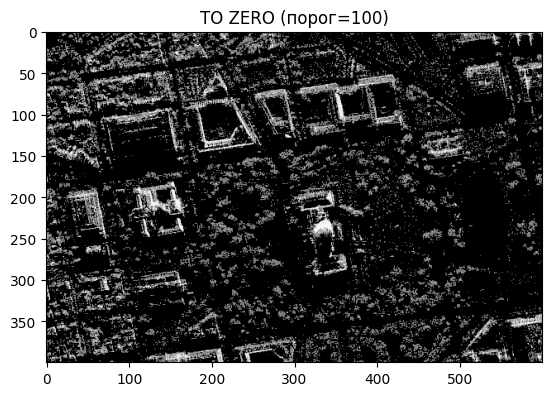

Порог 100 - THRESH_TOZERO: MSE=3000.3595


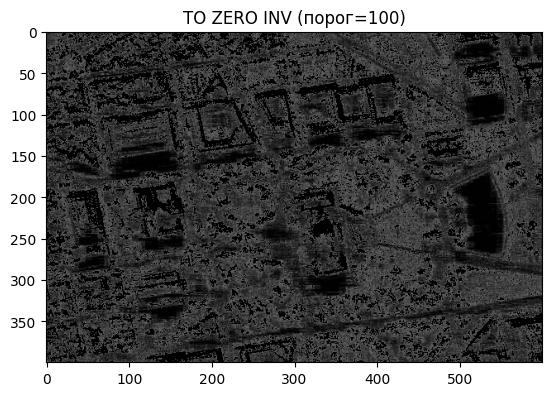

Порог 100 - THRESH_TOZERO_INV: MSE=4521.9411


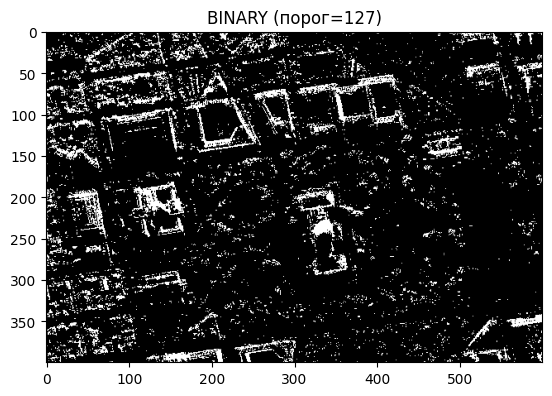

Порог 127 - BINARY: MSE=5603.9144


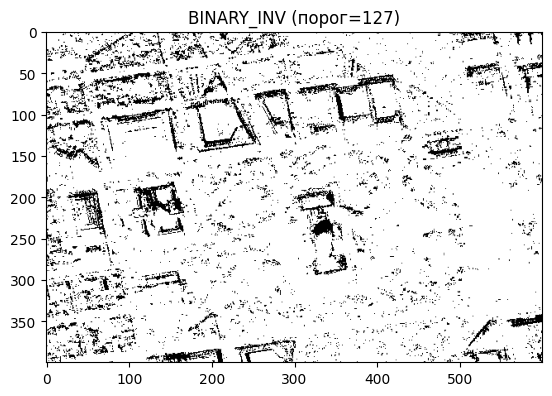

Порог 127 - BINARY_INV: MSE=36245.4858


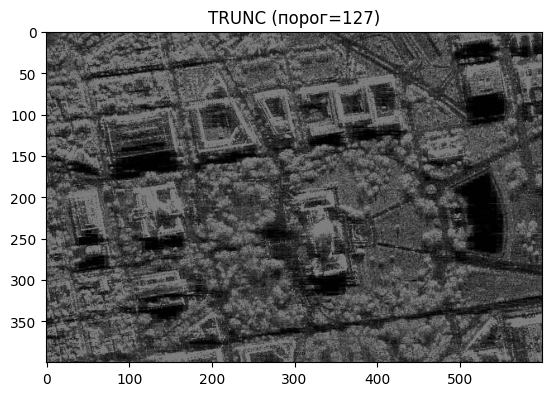

Порог 127 - THRESH_TRUNC: MSE=256.1402


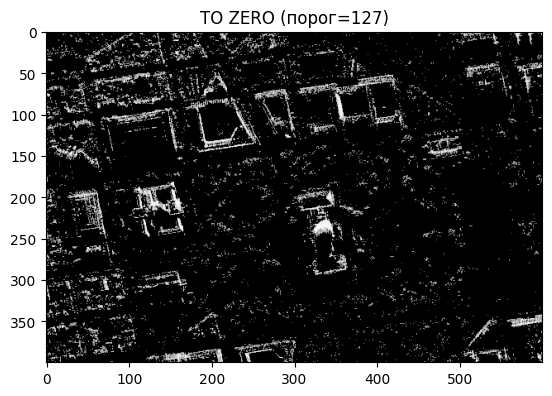

Порог 127 - THRESH_TOZERO: MSE=4617.9374


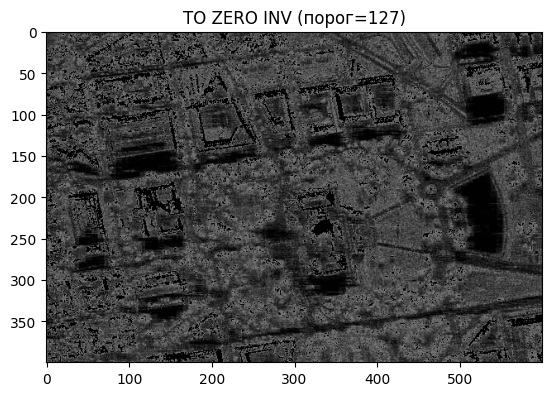

Порог 127 - THRESH_TOZERO_INV: MSE=2904.3632


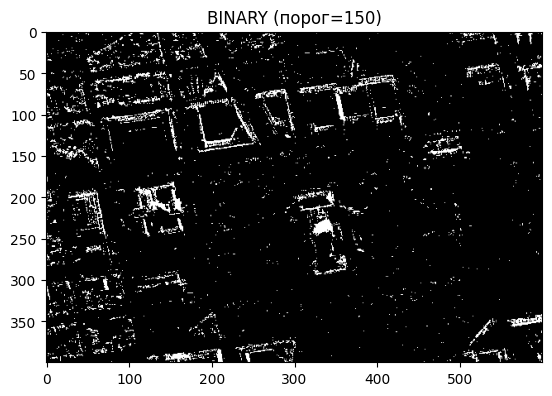

Порог 150 - BINARY: MSE=5859.9270


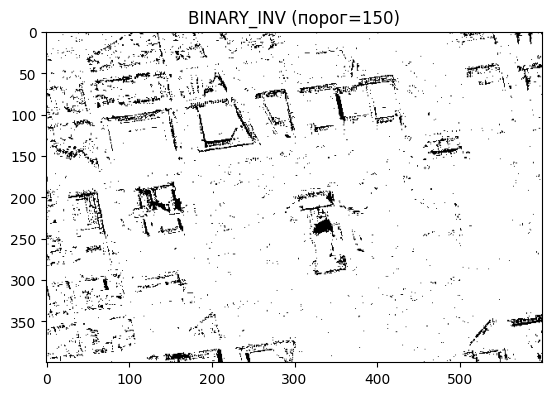

Порог 150 - BINARY_INV: MSE=35989.4732


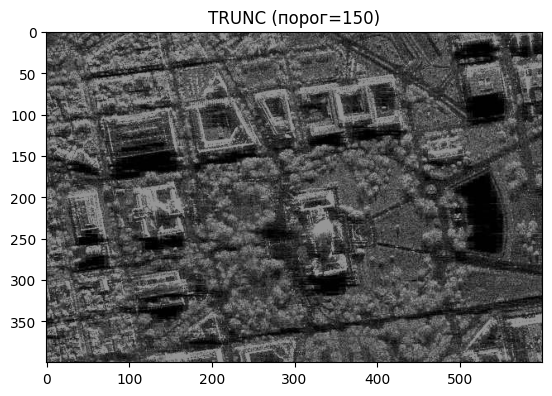

Порог 150 - THRESH_TRUNC: MSE=126.0787


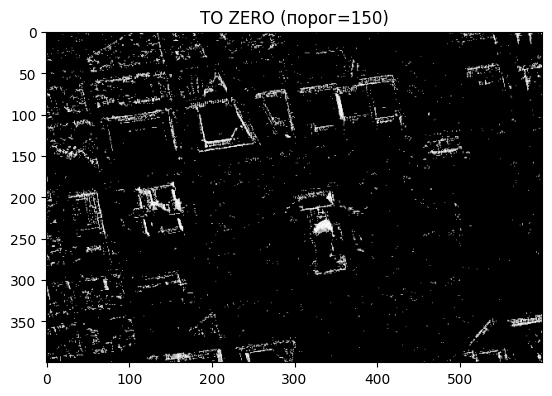

Порог 150 - THRESH_TOZERO: MSE=5559.7832


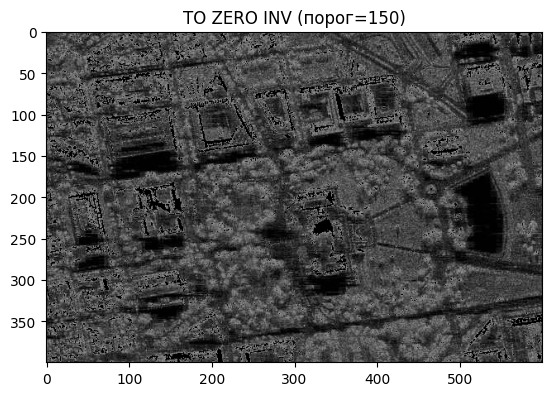

Порог 150 - THRESH_TOZERO_INV: MSE=1962.5174


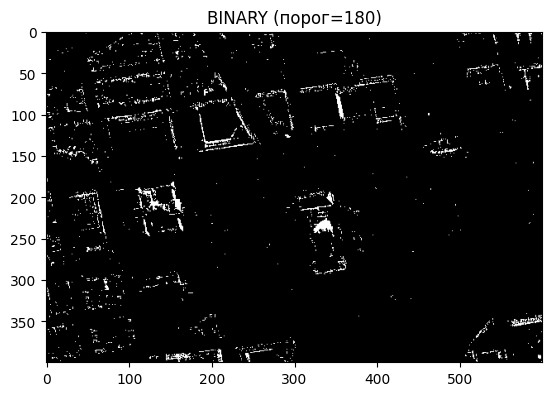

Порог 180 - BINARY: MSE=6384.7308


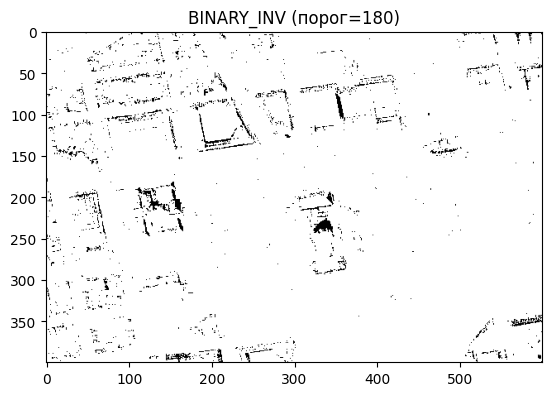

Порог 180 - BINARY_INV: MSE=35464.6694


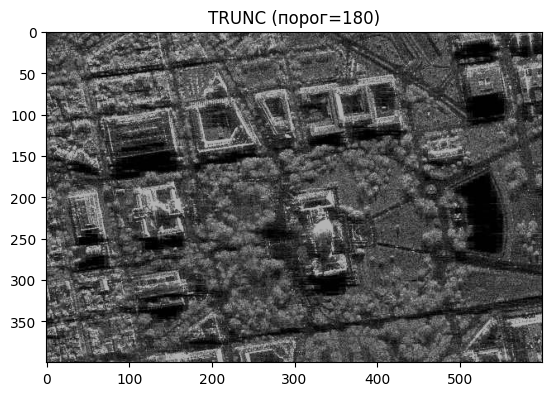

Порог 180 - THRESH_TRUNC: MSE=43.3833


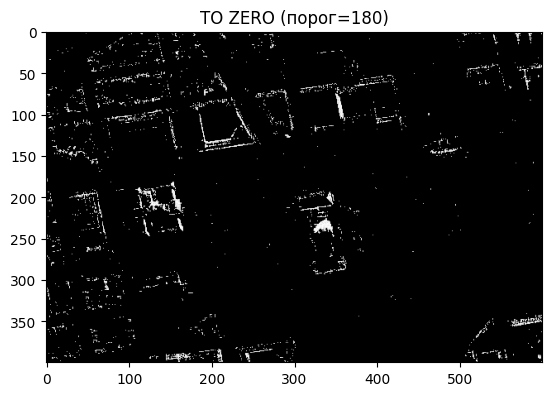

Порог 180 - THRESH_TOZERO: MSE=6325.1519


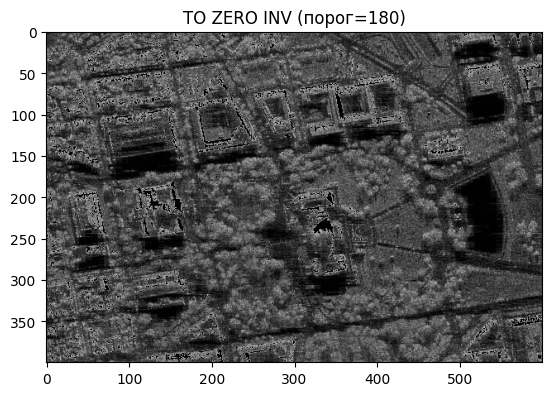

Порог 180 - THRESH_TOZERO_INV: MSE=1197.1488


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.metrics import structural_similarity, mean_squared_error

# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.
image = cv2.imread('C:\\Users\\Vladislav\\PycharmProjects\\image-processing\\Practice_1\\sar_1_gray.jpg')
plt.title("Исходное изображение")
plt.imshow(image)
plt.show()

# 2. Постройте гистограмму
histSize = 256
histRange = (0, 256)
accumulate = False
b = image[:, :, 0]
b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)
plt.plot(b_hist)
plt.title("Гистограмма яркости")
plt.show()

b_hist_cum = b_hist.cumsum()
plt.plot(b_hist_cum)
plt.title("Накопленная гистограмма")
plt.show()

b_hist_norm = b_hist / (image.shape[0] * image.shape[1])
plt.plot(b_hist_norm)
plt.title("Нормализованная гистограмма")
plt.show()


# 3. Реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
def gamma_correction(src, gamma):
    inv_gamma = 1 / gamma

    table = [((i / 255) ** inv_gamma) * 255 for i in range(256)]
    table = np.array(table, np.uint8)

    return cv2.LUT(src, table)


# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
gamma_less = 0.5
gamma_more = 1.5

image_gamma_less = gamma_correction(image, gamma_less)
image_gamma_more = gamma_correction(image, gamma_more)

# Преобразуем гамма-корректированные изображения в оттенки серого
gamma_less_gray = cv2.cvtColor(image_gamma_less, cv2.COLOR_BGR2GRAY)
gamma_more_gray = cv2.cvtColor(image_gamma_more, cv2.COLOR_BGR2GRAY)

plt.title(f"Гамма коррекция (γ={gamma_less})")
plt.imshow(image_gamma_less)
plt.show()

plt.title(f"Гамма коррекция (γ={gamma_more})")
plt.imshow(image_gamma_more)
plt.show()

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

(ssim, diff) = structural_similarity(image_gray, gamma_less_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM between source image and image with gamma 0.5: {}".format(ssim))

(ssim, diff_2) = structural_similarity(image_gray, gamma_more_gray, full=True)
diff_2 = (diff_2 * 255).astype("uint8")
print("SSIM between source image and image with gamma 1.5: {}".format(ssim))

mse = mean_squared_error(image_gray, gamma_less_gray)
print(f"MSE between original image and image with gamma 0.5: {mse:}")

mse_2 = mean_squared_error(image_gray, gamma_more_gray)
print(f"MSE between original image and image with gamma 1.5: {mse_2:}")


# 5. Реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
def statistical_color_correction(source, target):
    source_mean = np.mean(source)
    source_std = np.std(source)

    target_mean = np.mean(target)
    target_std = np.std(target)

    corrected = (source - source_mean) * (target_std / source_std) + target_mean
    corrected = np.clip(corrected, 0, 255)

    return corrected.astype(np.uint8)


eq_gray = cv2.equalizeHist(image_gray)
plt.title("Equalized image")
plt.imshow(eq_gray, cmap="gray")
plt.show()

image_stat_corrected = statistical_color_correction(image, eq_gray)
plt.title("Статистическая цветокоррекция")
plt.imshow(image_stat_corrected)
plt.show()

# 6. Тестирование пороговой фильтрации с различными параметрами
thresholds = [100, 127, 150, 180]
for i, threshold in enumerate(thresholds, 1):
    _, thresh_binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    _, thresh_binary_inv = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY_INV)
    _, thresh_trunc = cv2.threshold(image, threshold, 255, cv2.THRESH_TRUNC)
    _, thresh_tozero = cv2.threshold(image, threshold, 255, cv2.THRESH_TOZERO)
    _, thresh_tozero_inv = cv2.threshold(image, threshold, 255, cv2.THRESH_TOZERO_INV)

    plt.imshow(thresh_binary, cmap='gray')
    plt.title(f'BINARY (порог={threshold})')
    plt.show()

    mse_binary = mean_squared_error(image, thresh_binary)
    print(f"Порог {threshold} - BINARY: MSE={mse_binary:.4f}")

    plt.imshow(thresh_binary_inv, cmap='gray')
    plt.title(f'BINARY_INV (порог={threshold})')
    plt.show()

    mse_binary_inv = mean_squared_error(image, thresh_binary_inv)
    print(f"Порог {threshold} - BINARY_INV: MSE={mse_binary_inv:.4f}")

    plt.imshow(thresh_trunc, cmap='gray')
    plt.title(f'TRUNC (порог={threshold})')
    plt.show()

    mse_thresh_trunc = mean_squared_error(image, thresh_trunc)
    print(f"Порог {threshold} - THRESH_TRUNC: MSE={mse_thresh_trunc:.4f}")

    plt.imshow(thresh_tozero, cmap='gray')
    plt.title(f'TO ZERO (порог={threshold})')
    plt.show()

    mse_thresh_tozero = mean_squared_error(image, thresh_tozero)
    print(f"Порог {threshold} - THRESH_TOZERO: MSE={mse_thresh_tozero:.4f}")

    plt.imshow(thresh_tozero_inv, cmap='gray')
    plt.title(f'TO ZERO INV (порог={threshold})')
    plt.show()

    mse_thresh_tozero_inv = mean_squared_error(image, thresh_tozero_inv)
    print(f"Порог {threshold} - THRESH_TOZERO_INV: MSE={mse_thresh_tozero_inv:.4f}")
